<a href="https://colab.research.google.com/github/njwbilll/Tugas-2_scikit-learn-Cookbook-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/04_Building_Models_with_Distance_Metrics_and_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: Building Models with Distance Metrics and Nearest Neighbors

**Referensi:** scikit-learn Cookbook, Third Edition - John Sukup (Packt Publishing, 2025)

---

## Ringkasan Chapter

Chapter 4 membahas konsep jarak (distance) dalam Machine Learning dan algoritma K-Nearest Neighbors (KNN). KNN adalah algoritma supervised learning yang paling intuitif: ia mengklasifikasikan titik data baru berdasarkan mayoritas label dari tetangga terdekatnya dalam ruang fitur. Seperti seorang anak kecil yang bisa membedakan mobil dari kucing hanya dengan melihat karakteristiknya, KNN mengandalkan prinsip serupa untuk klasifikasi.

### Topik yang Dibahas:
1. Pengantar distance metrics (Euclidean, Manhattan, Minkowski)
2. Cara kerja algoritma KNN
3. Perbandingan distance metrics pada berbagai jenis dataset
4. Implementasi KNN untuk klasifikasi menggunakan scikit-learn
5. Hyperparameter tuning pada KNN (nilai k optimal, distance metric)
6. Evaluasi performa KNN (confusion matrix, classification report, cross-validation)

## Setup: Import Library

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(2024)
print("Library berhasil diimport.")

Library berhasil diimport.


## 1. Pengantar Distance Metrics

### Penjelasan Teori

**Distance metric (metrik jarak)** adalah cara mengukur seberapa mirip atau berbedanya dua titik data dalam ruang fitur. Pemilihan metrik jarak yang tepat sangat penting karena dapat secara signifikan mempengaruhi performa model, terutama KNN.

Bayangkan kamu harus membedakan antara seekor cheetah dan seekor puma. Keduanya berbagi banyak karakteristik: berkaki empat, memiliki ekor, memiliki cakar. Tapi keduanya sangat berbeda dari sebuah mobil Toyota. Ini adalah prinsip dasar distance metrics: mengukur seberapa "dekat" atau "jauh" dua objek dalam ruang karakteristiknya.

**Tiga metrik jarak utama dalam ML:**

**1. Euclidean Distance (Jarak Lurus)**
Jarak garis lurus antara dua titik dalam ruang n-dimensi. Ini adalah "jarak burung terbang" atau jarak terpendek antara dua titik.

Formula: `d(p, q) = sqrt(sum((p_i - q_i)^2))`

**2. Manhattan Distance (Jarak Blok Kota)**
Bayangkan menavigasi kota dengan grid persegi panjang seperti Manhattan, New York. Kamu hanya bisa bergerak secara horizontal atau vertikal, tidak diagonal. Lebih robust terhadap outlier dibanding Euclidean.

Formula: `d(p, q) = sum(|p_i - q_i|)`

**3. Minkowski Distance (Generalisasi)**
Generalisasi dari Euclidean dan Manhattan. Parameter `p` menentukan jenis jarak:
- `p = 1`: Manhattan distance
- `p = 2`: Euclidean distance
- `p = infinity`: Chebyshev distance

Formula: `d(p, q) = (sum(|p_i - q_i|^p))^(1/p)`

In [6]:
from scipy.spatial.distance import euclidean, cityblock, minkowski

# Dua titik data contoh (masing-masing memiliki 3 fitur)
point_a = np.array([1.0, 2.0, 3.0])
point_b = np.array([4.0, 6.0, 8.0])

# Menghitung ketiga metrik jarak
d_euclidean = euclidean(point_a, point_b)
d_manhattan = cityblock(point_a, point_b)
d_minkowski_p2 = minkowski(point_a, point_b, p=2)  # p=2 = Euclidean
d_minkowski_p3 = minkowski(point_a, point_b, p=3)

print("Titik A:", point_a)
print("Titik B:", point_b)
print()
print(f"Euclidean Distance:           {d_euclidean:.4f}")
print(f"Manhattan Distance:           {d_manhattan:.4f}")
print(f"Minkowski (p=2, =Euclidean):  {d_minkowski_p2:.4f}")
print(f"Minkowski (p=3):              {d_minkowski_p3:.4f}")

Titik A: [1. 2. 3.]
Titik B: [4. 6. 8.]

Euclidean Distance:           7.0711
Manhattan Distance:           12.0000
Minkowski (p=2, =Euclidean):  7.0711
Minkowski (p=3):              6.0000


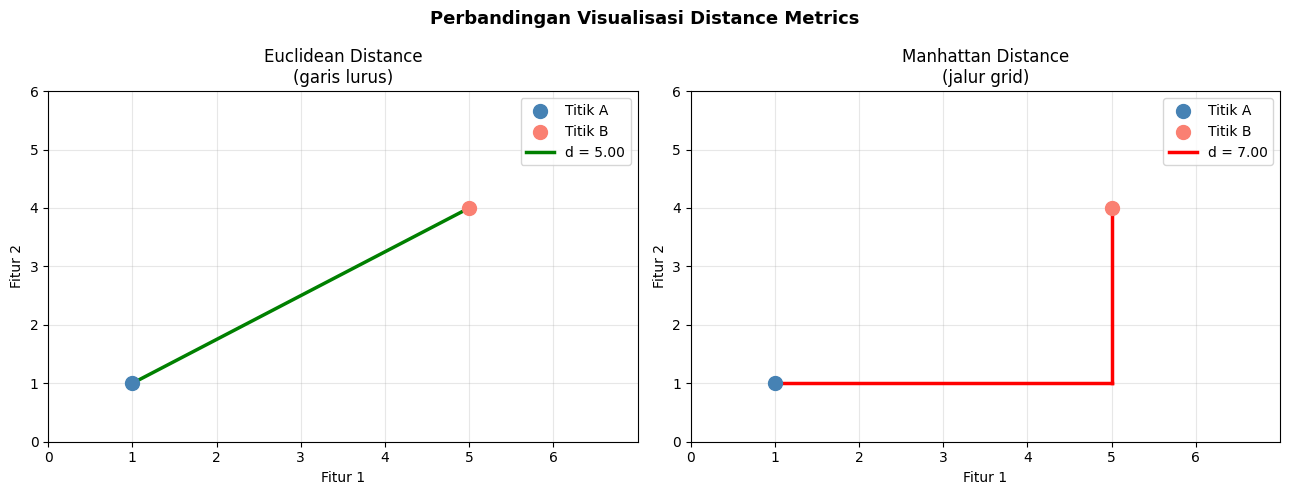

In [7]:
# Visualisasi intuitif: Euclidean vs Manhattan
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

p_start = np.array([1, 1])
p_end   = np.array([5, 4])

for ax, title, style in zip(
    axes,
    ["Euclidean Distance\n(garis lurus)", "Manhattan Distance\n(jalur grid)"],
    ["euclidean", "manhattan"]
):
    ax.scatter(*p_start, color='steelblue', s=100, zorder=5, label='Titik A')
    ax.scatter(*p_end,   color='salmon',    s=100, zorder=5, label='Titik B')

    if style == "euclidean":
        ax.plot([p_start[0], p_end[0]], [p_start[1], p_end[1]],
                'g-', linewidth=2.5, label=f'd = {euclidean(p_start, p_end):.2f}')
    else:
        # Rute Manhattan: gerak horizontal dulu, lalu vertikal
        ax.plot([p_start[0], p_end[0]], [p_start[1], p_start[1]],
                'r-', linewidth=2.5)
        ax.plot([p_end[0], p_end[0]], [p_start[1], p_end[1]],
                'r-', linewidth=2.5,
                label=f'd = {cityblock(p_start, p_end):.2f}')

    # Gambar grid tipis untuk Manhattan
    ax.set_xticks(range(0, 7))
    ax.set_yticks(range(0, 7))
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 7)
    ax.set_ylim(0, 6)
    ax.set_xlabel("Fitur 1")
    ax.set_ylabel("Fitur 2")
    ax.set_title(title)
    ax.legend()

plt.suptitle("Perbandingan Visualisasi Distance Metrics", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Memahami Algoritma KNN

### Penjelasan Teori

**K-Nearest Neighbors (KNN)** adalah algoritma supervised learning yang digunakan untuk tugas klasifikasi maupun regresi. Ide utamanya sangat sederhana: klasifikasikan titik data baru berdasarkan mayoritas label dari K tetangga terdekatnya dalam dataset training.

**Langkah-langkah kerja KNN:**

1. **Memilih K:** Parameter `k` merepresentasikan jumlah tetangga terdekat yang dipertimbangkan saat membuat prediksi.
   - K kecil: model sensitif terhadap noise, cenderung overfit.
   - K besar: prediksi lebih halus tapi bisa mengabaikan pola lokal, cenderung underfit.

2. **Menghitung jarak:** KNN menggunakan distance metric (Euclidean, Manhattan, dll.) untuk menentukan tetangga terdekat dari titik baru.

3. **Mekanisme voting:** Untuk klasifikasi, KNN memberikan label berdasarkan mayoritas voting dari K tetangga terdekatnya. Untuk regresi, menghitung rata-rata nilai tetangga.

**Karakteristik penting KNN:**
- KNN adalah algoritma **lazy learning**: tidak ada proses "training" eksplisit. Model menyimpan seluruh data training dan melakukan komputasi saat prediksi.
- KNN adalah algoritma **non-parametric**: tidak membuat asumsi tentang distribusi data yang mendasarinya.
- KNN **sensitif terhadap skala fitur**: selalu standardisasi data sebelum menggunakan KNN.
- KNN **sensitif terhadap fitur yang tidak relevan**: reduksi dimensi atau seleksi fitur dapat meningkatkan performa.

In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)

print(f"Ukuran data training: {X_train.shape}")
print(f"Ukuran data testing:  {X_test.shape}")
print(f"Kelas target: {iris.target_names}")

Ukuran data training: (120, 4)
Ukuran data testing:  (30, 4)
Kelas target: ['setosa' 'versicolor' 'virginica']


In [9]:
# Membuat dan melatih model KNN dasar (k=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Membuat prediksi
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"KNN (k=3) - Akurasi pada test set: {accuracy:.4f}")
print(f"Jumlah prediksi benar: {(y_pred == y_test).sum()} dari {len(y_test)}")

KNN (k=3) - Akurasi pada test set: 0.9333
Jumlah prediksi benar: 28 dari 30


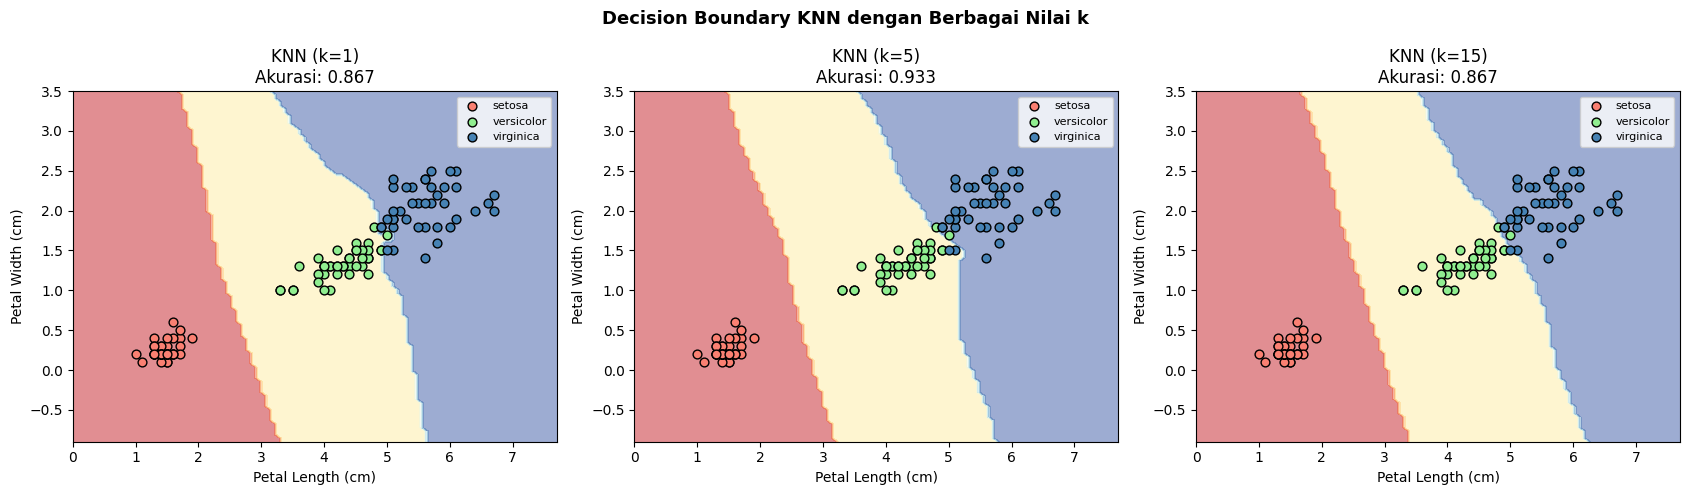

In [10]:
# Visualisasi decision boundary KNN (menggunakan 2 fitur pertama untuk 2D visualization)
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import StandardScaler

# Gunakan 2 fitur: petal length dan petal width (fitur paling informatif)
X_2d = X[:, 2:4]
X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y, test_size=0.2, random_state=2024
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
k_values = [1, 5, 15]
colors = ['salmon', 'lightgreen', 'steelblue']

for ax, k in zip(axes, k_values):
    knn_2d = KNeighborsClassifier(n_neighbors=k)
    knn_2d.fit(X_2d_train, y_2d_train)
    acc_2d = knn_2d.score(X_2d_test, y_2d_test)

    DecisionBoundaryDisplay.from_estimator(
        knn_2d, X_2d_train,
        ax=ax, response_method="predict",
        cmap='RdYlBu', alpha=0.5
    )

    for cls, color, name in zip([0, 1, 2], colors, iris.target_names):
        mask = y_2d_train == cls
        ax.scatter(X_2d_train[mask, 0], X_2d_train[mask, 1],
                   c=color, label=name, edgecolors='k', s=40)

    ax.set_xlabel('Petal Length (cm)')
    ax.set_ylabel('Petal Width (cm)')
    ax.set_title(f'KNN (k={k})\nAkurasi: {acc_2d:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Decision Boundary KNN dengan Berbagai Nilai k', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Perbandingan Distance Metrics

### Penjelasan Teori

Memilih metrik jarak yang tepat bergantung pada karakteristik dataset:

| Metrik | Cocok Untuk | Tidak Cocok Untuk |
|--------|------------|-------------------|
| **Euclidean** | Data kontinu, distribusi normal, outlier rendah | Data dengan banyak fitur kategorik |
| **Manhattan** | Data sparse, dataset dengan outlier, data berbasis grid | Data dengan hubungan non-linear yang kompleks |
| **Minkowski** | Fleksibel, bisa disesuaikan dengan nilai p | Memerlukan tuning parameter p tambahan |
| **Hamming** | Data kategorik atau biner | Data kontinu |
| **Cosine** | Teks/dokumen (orientasi lebih penting dari magnitude) | Data yang magnitude-nya penting |

**Panduan umum:**
- Untuk sebagian besar kasus dengan data numerik kontinu, **Euclidean** adalah pilihan default.
- Gunakan **Manhattan** ketika terdapat outlier atau ketika absolute differences lebih bermakna dari squared differences.
- Gunakan **Cosine** untuk data teks atau data berdimensi sangat tinggi.

In [11]:
from sklearn.datasets import make_circles
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

n_samples = 300

# Dataset 1: Lingkaran bersarang (circular) - Euclidean seharusnya lebih baik
X_circles, y_circles = make_circles(n_samples=n_samples, noise=0.3, factor=0.3)
X_circ_train, X_circ_test, y_circ_train, y_circ_test = train_test_split(
    X_circles, y_circles, test_size=0.2, random_state=2024
)

# Dataset 2: Checkerboard (pola grid) - Manhattan seharusnya lebih baik
x_grid = np.linspace(0, 4, int(np.sqrt(n_samples)))
y_grid = np.linspace(0, 4, int(np.sqrt(n_samples)))
xx, yy = np.meshgrid(x_grid, y_grid)
X_check = np.column_stack((xx.ravel(), yy.ravel()))
y_check = np.mod(np.floor(xx.ravel()) + np.floor(yy.ravel()), 2)
X_check_train, X_check_test, y_check_train, y_check_test = train_test_split(
    X_check, y_check, test_size=0.2, random_state=2024
)

print("Dataset yang dibuat:")
print(f"  Circles: {X_circles.shape}, kelas: {np.unique(y_circles)}")
print(f"  Checkerboard: {X_check.shape}, kelas: {np.unique(y_check)}")

Dataset yang dibuat:
  Circles: (300, 2), kelas: [0 1]
  Checkerboard: (289, 2), kelas: [0. 1.]


In [12]:
# Bandingkan distance metrics pada kedua dataset
metrics_list = ['euclidean', 'manhattan', 'minkowski']
results = {'circles': {}, 'checkerboard': {}}

for metric in metrics_list:
    # Circles dataset
    knn_c = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_c.fit(X_circ_train, y_circ_train)
    results['circles'][metric] = knn_c.score(X_circ_test, y_circ_test)

    # Checkerboard dataset
    knn_m = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_m.fit(X_check_train, y_check_train)
    results['checkerboard'][metric] = knn_m.score(X_check_test, y_check_test)

# Tampilkan hasil sebagai tabel
results_df = pd.DataFrame(results, index=metrics_list)
results_df.index.name = 'Distance Metric'
print("Akurasi KNN (k=3) per distance metric dan dataset:")
display(results_df.round(4))

Akurasi KNN (k=3) per distance metric dan dataset:


,circles,checkerboard
Distance Metric,,
euclidean,0.7833,0.8103
manhattan,0.7667,0.8448
minkowski,0.7833,0.8103


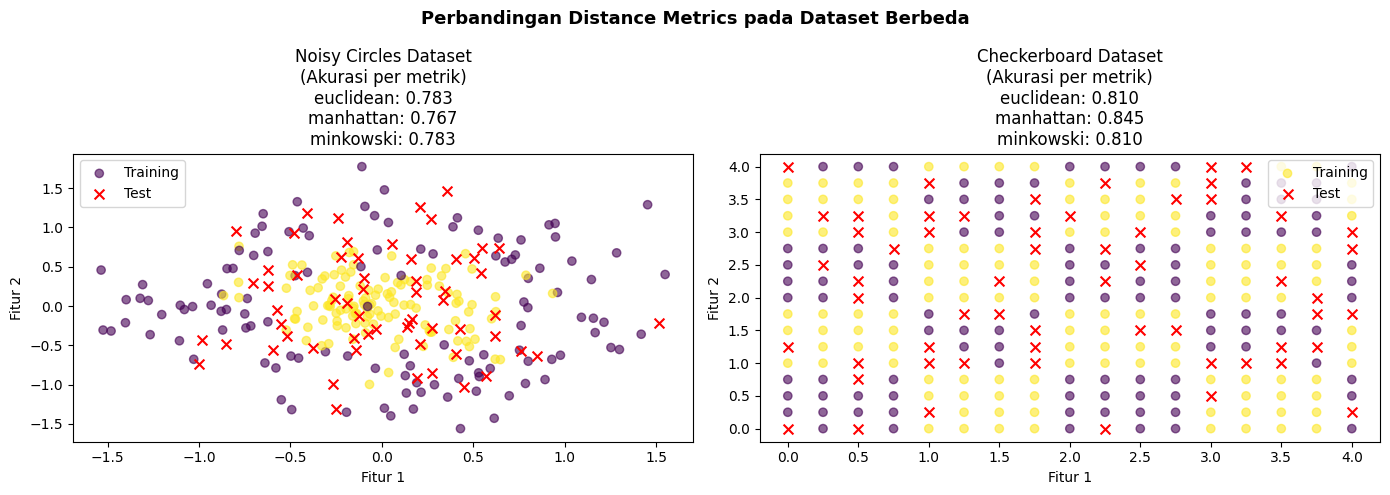

Catatan: Pada checkerboard dataset, Manhattan biasanya lebih baik karena pola grid-nya.


In [13]:
# Visualisasi kedua dataset dengan akurasi masing-masing metrik
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel kiri: Circles dataset
ax1.scatter(X_circ_train[:, 0], X_circ_train[:, 1],
            c=y_circ_train, cmap='viridis', alpha=0.6, label='Training')
ax1.scatter(X_circ_test[:, 0], X_circ_test[:, 1],
            c='red', marker='x', s=50, label='Test')
info1 = '\n'.join([f"{m}: {results['circles'][m]:.3f}" for m in metrics_list])
ax1.set_title(f'Noisy Circles Dataset\n(Akurasi per metrik)\n{info1}')
ax1.legend()
ax1.set_xlabel('Fitur 1')
ax1.set_ylabel('Fitur 2')

# Panel kanan: Checkerboard dataset
ax2.scatter(X_check_train[:, 0], X_check_train[:, 1],
            c=y_check_train, cmap='viridis', alpha=0.6, label='Training')
ax2.scatter(X_check_test[:, 0], X_check_test[:, 1],
            c='red', marker='x', s=50, label='Test')
info2 = '\n'.join([f"{m}: {results['checkerboard'][m]:.3f}" for m in metrics_list])
ax2.set_title(f'Checkerboard Dataset\n(Akurasi per metrik)\n{info2}')
ax2.legend()
ax2.set_xlabel('Fitur 1')
ax2.set_ylabel('Fitur 2')

plt.suptitle('Perbandingan Distance Metrics pada Dataset Berbeda', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Catatan: Pada checkerboard dataset, Manhattan biasanya lebih baik karena pola grid-nya.")

## 4. Implementasi KNN di scikit-learn

### Penjelasan Teori

scikit-learn menyediakan `KNeighborsClassifier()` untuk klasifikasi dan `KNeighborsRegressor()` untuk regresi. Keduanya mengikuti API standar scikit-learn: `fit()`, `predict()`, dan `score()`.

**Parameter penting `KNeighborsClassifier()`:**
- `n_neighbors` (default=5): Jumlah tetangga yang dipertimbangkan.
- `weights` (default='uniform'): Cara pembobotan tetangga:
  - `'uniform'`: Semua tetangga diberi bobot sama.
  - `'distance'`: Tetangga yang lebih dekat diberi bobot lebih besar.
- `metric` (default='minkowski'): Metrik jarak yang digunakan.
- `p` (default=2): Parameter Minkowski (p=2 = Euclidean, p=1 = Manhattan).
- `algorithm` (default='auto'): Algoritma pencarian tetangga (ball_tree, kd_tree, brute).
- `n_jobs` (default=1): Jumlah CPU untuk komputasi paralel (-1 = gunakan semua).

**Penting:** KNN sangat sensitif terhadap skala fitur. Selalu gunakan `StandardScaler()` atau `MinMaxScaler()` sebelum KNN, sebaiknya dalam Pipeline.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)
import seaborn as sns

# Load dan split dataset Iris
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)

# Pipeline: StandardScaler + KNN (best practice)
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
])

knn_pipeline.fit(X_train, y_train)
y_pred = knn_pipeline.predict(X_test)

print(f"Akurasi KNN (pipeline, k=5, weights='distance'): {accuracy_score(y_test, y_pred):.4f}")

Akurasi KNN (pipeline, k=5, weights='distance'): 0.9333


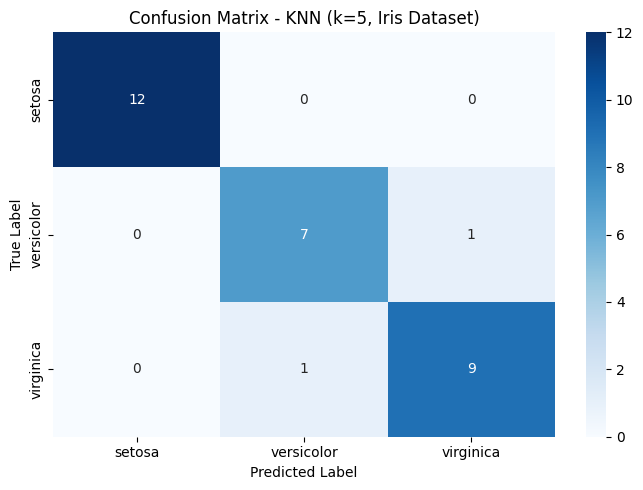

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - KNN (k=5, Iris Dataset)')
plt.tight_layout()
plt.show()

In [16]:
# Classification report
report = classification_report(
    y_test, y_pred,
    target_names=iris.target_names,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()
print("Classification Report:")
display(report_df.round(4))

Classification Report:


,precision,recall,f1-score,support
setosa,1.0000,1.0000,1.0000,12.0000
versicolor,0.8750,0.8750,0.8750,8.0000
virginica,0.9000,0.9000,0.9000,10.0000
accuracy,0.9333,0.9333,0.9333,0.9333
macro avg,0.9250,0.9250,0.9250,30.0000
weighted avg,0.9333,0.9333,0.9333,30.0000


## 5. Hyperparameter Tuning pada KNN

### Penjelasan Teori

Performa KNN sangat bergantung pada pemilihan hyperparameter yang tepat, terutama:

**1. Nilai K (n_neighbors):**
Ini adalah hyperparameter yang paling penting. Strategi untuk memilih nilai K optimal:
- **Cross-validation:** Evaluasi performa model pada berbagai nilai K menggunakan CV.
- **Elbow method:** Plot akurasi terhadap berbagai nilai K dan identifikasi "elbow point" di mana penambahan K tidak lagi meningkatkan performa secara signifikan.

**2. Metrik jarak (metric):**
Pilih berdasarkan karakteristik data (lihat Bagian 3).

**3. Pembobotan tetangga (weights):**
- `'uniform'`: Semua tetangga diperlakukan sama.
- `'distance'`: Tetangga yang lebih dekat mendapat pengaruh lebih besar. Seringkali menghasilkan performa yang lebih baik.

**GridSearchCV** adalah alat terbaik untuk mencari kombinasi hyperparameter optimal secara otomatis melalui exhaustive search.

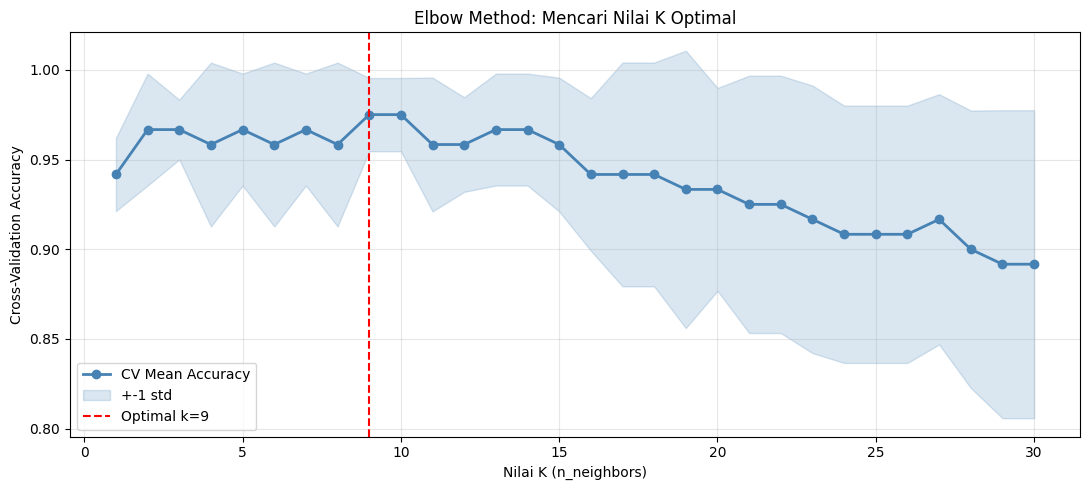

Nilai k optimal: 9
CV accuracy rata-rata pada k=9: 0.9750


In [17]:
# Elbow method: mencari nilai k optimal
from sklearn.model_selection import cross_val_score

k_range = range(1, 31)
cv_scores_mean = []
cv_scores_std  = []

for k in k_range:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_k, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

cv_scores_mean = np.array(cv_scores_mean)
cv_scores_std  = np.array(cv_scores_std)

# Temukan k dengan akurasi CV tertinggi
optimal_k = k_range[np.argmax(cv_scores_mean)]

plt.figure(figsize=(11, 5))
plt.plot(k_range, cv_scores_mean, marker='o', color='steelblue', linewidth=2, label='CV Mean Accuracy')
plt.fill_between(k_range,
                 cv_scores_mean - cv_scores_std,
                 cv_scores_mean + cv_scores_std,
                 alpha=0.2, color='steelblue', label='+-1 std')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
plt.xlabel('Nilai K (n_neighbors)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Elbow Method: Mencari Nilai K Optimal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Nilai k optimal: {optimal_k}")
print(f"CV accuracy rata-rata pada k={optimal_k}: {cv_scores_mean[optimal_k-1]:.4f}")

In [18]:
from sklearn.model_selection import GridSearchCV

# GridSearchCV: mencari kombinasi hyperparameter terbaik secara otomatis
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights':     ['uniform', 'distance'],
    'knn__metric':      ['euclidean', 'manhattan', 'minkowski'],
    'knn__p':           [1, 2]
}

pipeline_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

grid_search = GridSearchCV(
    estimator=pipeline_gs,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("GridSearchCV selesai.")
print(f"Hyperparameter terbaik: {grid_search.best_params_}")
print(f"Akurasi CV terbaik:     {grid_search.best_score_:.4f}")
print(f"Akurasi pada test set:  {grid_search.best_estimator_.score(X_test, y_test):.4f}")

GridSearchCV selesai.
Hyperparameter terbaik: {'knn__metric': 'manhattan', 'knn__n_neighbors': 7, 'knn__p': 1, 'knn__weights': 'uniform'}
Akurasi CV terbaik:     0.9833
Akurasi pada test set:  0.9000


## 6. Evaluasi Performa KNN

### Penjelasan Teori

Evaluasi model klasifikasi melibatkan beberapa metrik yang memberikan gambaran holistik tentang performa model. Mengandalkan hanya satu metrik, seperti akurasi, bisa menyesatkan terutama untuk dataset yang tidak seimbang (imbalanced).

**Metrik evaluasi utama untuk klasifikasi:**

1. **Accuracy:** Proporsi prediksi yang benar dari total prediksi.
   - `Accuracy = (TP + TN) / (TP + TN + FP + FN)`
   - Bisa menyesatkan untuk kelas yang tidak seimbang.

2. **Precision:** Dari semua yang diprediksi positif, berapa yang benar-benar positif?
   - `Precision = TP / (TP + FP)`
   - Penting ketika false positive sangat merugikan.

3. **Recall (Sensitivity):** Dari semua yang benar-benar positif, berapa yang berhasil terdeteksi?
   - `Recall = TP / (TP + FN)`
   - Penting ketika false negative sangat merugikan (misalnya, deteksi penyakit).

4. **F1-Score:** Harmonic mean dari precision dan recall. Berguna ketika mencari keseimbangan antara keduanya.
   - `F1 = 2 * (Precision * Recall) / (Precision + Recall)`

5. **Confusion Matrix:** Tabel yang menunjukkan distribusi prediksi benar dan salah untuk setiap kelas. Sangat berguna untuk memahami di mana model membuat kesalahan.

6. **ROC-AUC:** Area under the ROC curve. Mengukur kemampuan model membedakan antar kelas terlepas dari threshold. AUC = 1 adalah model sempurna.

In [19]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

# Gunakan model terbaik dari GridSearchCV
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)
y_prob_best = best_knn.predict_proba(X_test)

# Hitung semua metrik utama
acc  = accuracy_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best, average='weighted')
rec  = recall_score(y_test, y_pred_best, average='weighted')
f1   = f1_score(y_test, y_pred_best, average='weighted')

# ROC-AUC untuk multiclass (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
auc = roc_auc_score(y_test_bin, y_prob_best, multi_class='ovr')

print("Ringkasan Evaluasi KNN (Model Terbaik dari GridSearchCV):")
print(f"  Accuracy:           {acc:.4f}")
print(f"  Precision (weighted): {prec:.4f}")
print(f"  Recall (weighted):    {rec:.4f}")
print(f"  F1-Score (weighted):  {f1:.4f}")
print(f"  ROC-AUC (OvR):       {auc:.4f}")

Ringkasan Evaluasi KNN (Model Terbaik dari GridSearchCV):
  Accuracy:           0.9000
  Precision (weighted): 0.9037
  Recall (weighted):    0.9000
  F1-Score (weighted):  0.9003
  ROC-AUC (OvR):       0.9562


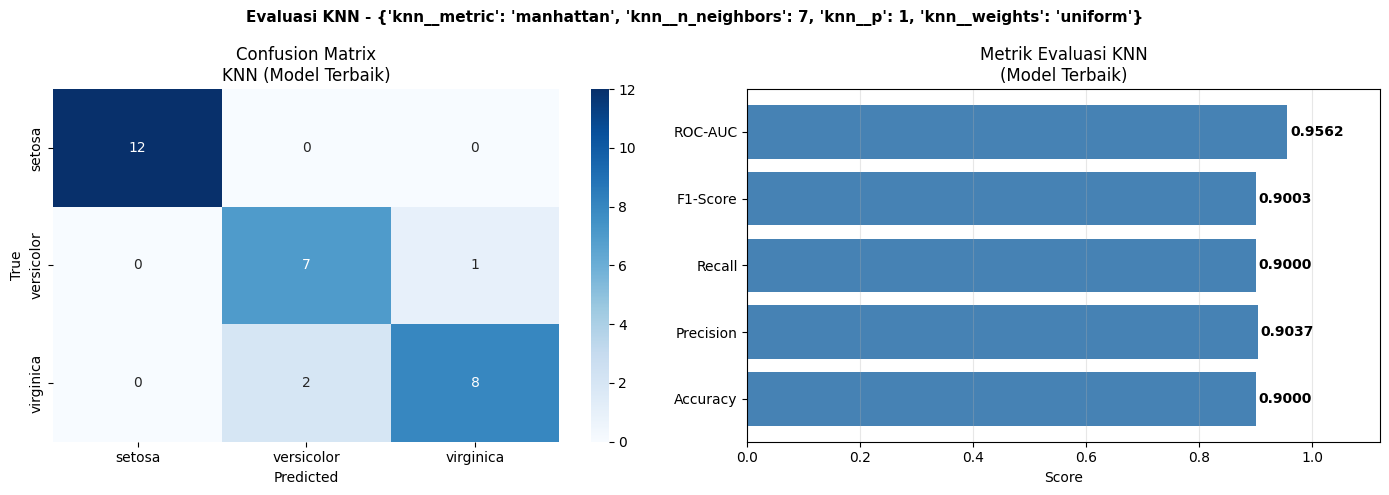

In [20]:
# Confusion matrix untuk model terbaik
cm_best = confusion_matrix(y_test, y_pred_best)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel kiri: Confusion Matrix
sns.heatmap(
    cm_best, annot=True, fmt='d', cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    ax=ax1
)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')
ax1.set_title('Confusion Matrix\nKNN (Model Terbaik)')

# Panel kanan: Perbandingan metrik evaluasi
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [acc, prec, rec, f1, auc]
bars = ax2.barh(metrics_names, metrics_values, color='steelblue')
for bar, val in zip(bars, metrics_values):
    ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontweight='bold')
ax2.set_xlim(0, 1.12)
ax2.set_xlabel('Score')
ax2.set_title('Metrik Evaluasi KNN\n(Model Terbaik)')
ax2.grid(True, alpha=0.3, axis='x')

plt.suptitle(f'Evaluasi KNN - {grid_search.best_params_}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

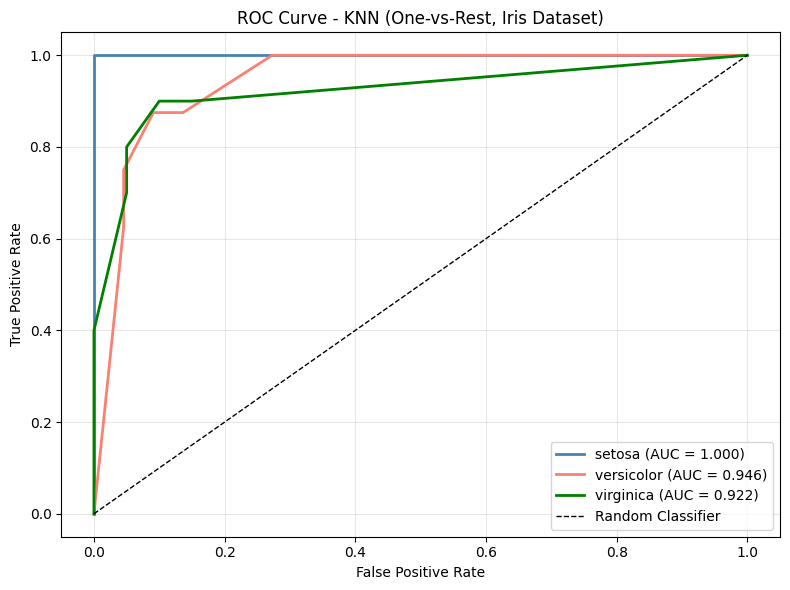

In [21]:
# ROC Curve untuk multiclass (One-vs-Rest)
from sklearn.metrics import roc_curve, auc as auc_score

fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['steelblue', 'salmon', 'green']

for i, (cls, color) in enumerate(zip(iris.target_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_best[:, i])
    roc_auc_cls  = auc_score(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls} (AUC = {roc_auc_cls:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - KNN (One-vs-Rest, Iris Dataset)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. KNN untuk Regresi

### Penjelasan Teori

Selain klasifikasi, KNN juga dapat digunakan untuk tugas regresi menggunakan `KNeighborsRegressor()`. Alih-alih menggunakan majority voting, KNN untuk regresi menggunakan **rata-rata** (atau rata-rata tertimbang berdasarkan jarak) dari nilai target tetangga terdekatnya sebagai prediksi.

**Metrik evaluasi untuk regresi:**
- **MSE (Mean Squared Error):** Rata-rata kuadrat selisih antara nilai prediksi dan aktual.
- **RMSE (Root MSE):** Akar kuadrat dari MSE. Lebih mudah diinterpretasikan karena satuan sama dengan target.
- **R-squared (R2):** Proporsi varians dalam target yang dijelaskan oleh model. R2 = 1 adalah model sempurna.

In [22]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset California Housing (data regresi)
housing = fetch_california_housing()
X_reg, y_reg = housing.data, housing.target

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# KNN Regression Pipeline
knn_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn_reg', KNeighborsRegressor(n_neighbors=5, weights='distance'))
])
knn_reg_pipeline.fit(X_reg_train, y_reg_train)
y_reg_pred = knn_reg_pipeline.predict(X_reg_test)

mse  = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_reg_test, y_reg_pred)

print("KNN Regresi - California Housing Dataset:")
print(f"  MSE:   {mse:.4f}")
print(f"  RMSE:  {rmse:.4f}")
print(f"  R2:    {r2:.4f}")

KNN Regresi - California Housing Dataset:
  MSE:   0.4300
  RMSE:  0.6557
  R2:    0.6719


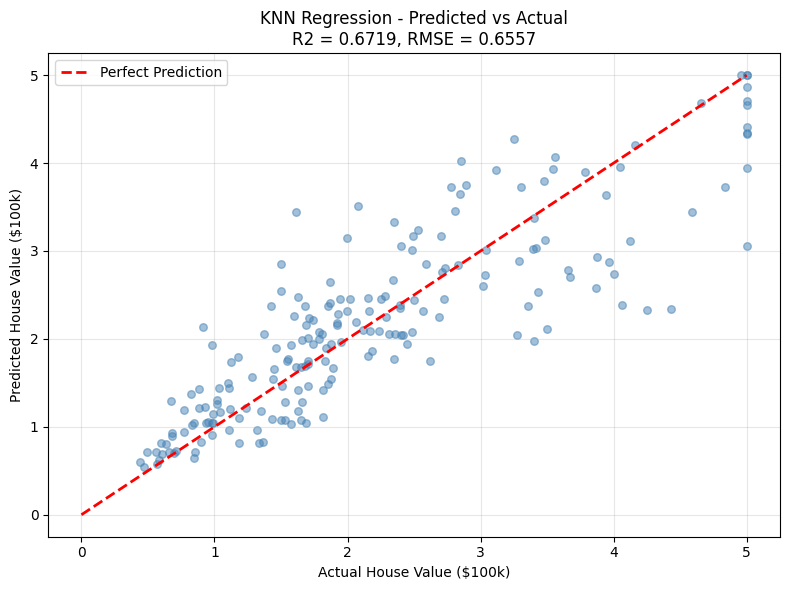

In [23]:
# Visualisasi: Predicted vs Actual (subset 200 sampel agar tidak terlalu padat)
sample_idx = np.random.choice(len(y_reg_test), size=200, replace=False)

plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test[sample_idx], y_reg_pred[sample_idx],
            alpha=0.5, color='steelblue', s=30)
max_val = max(y_reg_test.max(), y_reg_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual House Value ($100k)')
plt.ylabel('Predicted House Value ($100k)')
plt.title(f'KNN Regression - Predicted vs Actual\nR2 = {r2:.4f}, RMSE = {rmse:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Ringkasan Chapter 4

| Konsep | Kelas / Fungsi | Deskripsi |
|--------|----------------|-----------|
| KNN Klasifikasi | `KNeighborsClassifier()` | Klasifikasi berdasarkan majority voting dari K tetangga |
| KNN Regresi | `KNeighborsRegressor()` | Prediksi berdasarkan rata-rata nilai K tetangga |
| Jarak Euclidean | `metric='euclidean'` | Jarak garis lurus; pilihan default yang baik |
| Jarak Manhattan | `metric='manhattan'` | Jarak jalur grid; lebih robust terhadap outlier |
| Jarak Minkowski | `metric='minkowski'` | Generalisasi Euclidean dan Manhattan |
| Tuning K | Elbow method + CV | Plot CV accuracy vs K, cari "elbow point" |
| Hyperparameter search | `GridSearchCV()` | Cari kombinasi hyperparameter optimal |
| Confusion Matrix | `confusion_matrix()` | Visualisasikan distribusi prediksi benar/salah |
| ROC-AUC | `roc_auc_score()` | Ukur kemampuan diskriminasi model |

### Poin Kunci untuk Diingat:

1. **KNN adalah lazy learner:** Tidak ada proses training. Semua komputasi dilakukan saat prediksi, sehingga lambat pada dataset besar.

2. **Selalu scale data sebelum KNN:** KNN sangat sensitif terhadap skala fitur. Gunakan `StandardScaler()` atau `MinMaxScaler()` dalam Pipeline.

3. **Pilih K dengan cross-validation:** K kecil = overfit, K besar = underfit. Gunakan Elbow method atau `GridSearchCV`.

4. **Pilih distance metric berdasarkan data:** Euclidean untuk kasus umum, Manhattan untuk data berbasis grid atau yang memiliki banyak outlier.

5. **KNN bekerja buruk pada dimensi tinggi (Curse of Dimensionality):** Semakin banyak fitur, semakin "jauh" semua titik satu sama lain. Lakukan reduksi dimensi (PCA, dll.) terlebih dahulu jika perlu.

6. **`weights='distance'`** seringkali lebih baik dari `'uniform'` karena memberi bobot lebih pada tetangga yang lebih dekat.